# Rethinking LTV: Cohorts, Retention, and Incremental Value

Lifetime value is often presented as a standalone model. In real marketing analytics work, it is more useful to treat LTV as a decision framework.

The practical question is not only:

> How much value will this customer generate?

It is also:

> How much value is incremental because of a marketing action?

This notebook builds a synthetic customer panel to demonstrate four connected ideas:

1. Cohort LTV: how value accumulates over customer age.
2. Retention curves: how many customers remain active over time.
3. Survival-adjusted LTV: how future value changes when we account for churn.
4. Incremental LTV: why observed treated-vs-untreated value can be biased.

The data is generated inside the notebook. It is designed to look like a customer transaction panel, but the treatment, retention, and causal effects are simulated so the true structure is known.

## Step 0 — Create a semi-synthetic customer panel

The goal is not to perfectly reproduce a real business. The goal is to create a realistic enough environment where the main LTV issues are visible.

We simulate customers with different levels of historical engagement and monetary value. Then we create monthly records, treatment exposure, churn, conversion, and value.

The important design choice is that treatment is not randomly assigned. Higher-value customers are more likely to be targeted. This creates selection bias, which is exactly the problem that often makes observed LTV misleading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)

# -----------------------------
# Simulation settings
# -----------------------------
N_CUSTOMERS = 50_000
N_MONTHS = 12
DISCOUNT_RATE_MONTHLY = 0.01

# -----------------------------
# Customer-level heterogeneity
# -----------------------------
customers = pd.DataFrame({
    "customer_id": np.arange(N_CUSTOMERS),
})

# Cohort month is the first active month. This lets us compare customers by age since acquisition.
customers["cohort_month"] = np.random.choice(np.arange(1, 7), size=N_CUSTOMERS, p=[0.18, 0.17, 0.17, 0.16, 0.16, 0.16])

# Latent customer quality drives spend, conversion, retention, and targeting probability.
customers["customer_quality"] = np.random.normal(0, 1, N_CUSTOMERS)

# Public-dataset-like behavioral features. These are not real public data; they mimic common transaction features.
customers["historical_frequency"] = np.random.poisson(lam=np.exp(1.1 + 0.35 * customers["customer_quality"]))
customers["historical_monetary"] = np.random.lognormal(mean=3.2 + 0.35 * customers["customer_quality"], sigma=0.55)
customers["recency"] = np.clip(np.random.normal(45 - 8 * customers["customer_quality"], 18, N_CUSTOMERS), 1, 120)

# Simple customer segments based on historical monetary value.
customers["customer_segment"] = pd.qcut(
    customers["historical_monetary"],
    q=3,
    labels=["low_value", "mid_value", "high_value"]
)

# Baseline conversion propensity: what would happen without treatment.
logit_base = (
    -3.4
    + 0.35 * customers["customer_quality"]
    + 0.025 * customers["historical_frequency"]
    - 0.006 * customers["recency"]
)
customers["baseline_propensity"] = 1 / (1 + np.exp(-logit_base))

# Baseline monthly value conditional on conversion.
customers["baseline_order_value"] = 20 + 0.55 * customers["historical_monetary"] + np.random.normal(0, 8, N_CUSTOMERS)
customers["baseline_order_value"] = customers["baseline_order_value"].clip(lower=5)

customers.head()

,customer_id,cohort_month,customer_quality,historical_frequency,historical_monetary,recency,customer_segment,baseline_propensity,baseline_order_value
0,0,3,-0.019063,3,20.796782,48.554004,mid_value,0.026008,21.000071
1,1,6,1.207288,6,13.759468,46.345481,low_value,0.042880,17.735016
2,2,5,0.625292,2,38.360114,43.901992,high_value,0.032466,48.544132
3,3,4,-0.804689,1,41.829695,53.988580,high_value,0.018333,45.811020
4,4,1,1.787113,7,67.892000,33.152118,high_value,0.057409,43.059870


The customer table creates realistic variation before any marketing action happens. Some customers have higher frequency, higher monetary value, lower recency, and higher baseline propensity.

This matters because targeting systems often prefer these customers. If we later compare treated and untreated customers directly, treated customers may look better even if the treatment itself caused only a modest lift.

In [2]:
# -----------------------------
# Expand to customer-month panel
# -----------------------------
panel = customers.loc[customers.index.repeat(N_MONTHS)].copy()
panel["calendar_month"] = np.tile(np.arange(1, N_MONTHS + 1), N_CUSTOMERS)
panel["months_since_cohort"] = panel["calendar_month"] - panel["cohort_month"] + 1

# Keep only months where the customer has already entered the population.
panel = panel[panel["months_since_cohort"] >= 1].copy()

# Treatment assignment is intentionally biased.
# Higher-quality and higher-value customers are more likely to receive the offer.
treat_logit = (
    -1.5
    + 0.75 * panel["customer_quality"]
    + 0.012 * panel["historical_frequency"]
    + 0.007 * panel["historical_monetary"]
    - 0.004 * panel["recency"]
)
panel["treatment_probability"] = 1 / (1 + np.exp(-treat_logit))
panel["treatment"] = np.random.binomial(1, panel["treatment_probability"])

# True treatment effects are known because this is simulated.
# Treatment modestly increases conversion and slightly improves retention.
panel["true_conversion_lift"] = 0.025
panel["true_retention_lift"] = 0.010

# Base churn probability decreases for better customers.
base_churn = (
    0.18
    - 0.025 * panel["customer_quality"]
    - 0.0007 * panel["historical_monetary"]
    + 0.005 * panel["months_since_cohort"]
)

panel["monthly_churn_probability"] = (
    base_churn
    - panel["true_retention_lift"] * panel["treatment"]
).clip(0.02, 0.45)

# Simulate active status. Once a customer churns, they stay inactive.
panel = panel.sort_values(["customer_id", "calendar_month"]).reset_index(drop=True)
panel["active_flag"] = 0
panel["churn_flag"] = 0

for customer_id, idx in panel.groupby("customer_id").groups.items():
    active = True
    for i in idx:
        if active:
            panel.at[i, "active_flag"] = 1
            churn = np.random.binomial(1, panel.at[i, "monthly_churn_probability"])
            panel.at[i, "churn_flag"] = churn
            if churn == 1:
                active = False
        else:
            panel.at[i, "active_flag"] = 0
            panel.at[i, "churn_flag"] = 0

# Conversion probability is active-dependent and treatment-dependent.
panel["conversion_probability"] = (
    panel["baseline_propensity"]
    + panel["true_conversion_lift"] * panel["treatment"]
).clip(0, 0.80)

panel["conversion"] = np.random.binomial(1, panel["conversion_probability"] * panel["active_flag"])

# Monthly value is realized only when active and converted.
noise = np.random.normal(0, 10, len(panel))
panel["monthly_value"] = (
    panel["conversion"]
    * (panel["baseline_order_value"] + 5 * panel["treatment"] + noise)
).clip(lower=0)

panel["discount_factor"] = 1 / ((1 + DISCOUNT_RATE_MONTHLY) ** (panel["months_since_cohort"] - 1))
panel["discounted_monthly_value"] = panel["monthly_value"] * panel["discount_factor"]

panel.head()

,customer_id,cohort_month,customer_quality,historical_frequency,historical_monetary,recency,customer_segment,baseline_propensity,baseline_order_value,calendar_month,...,true_conversion_lift,true_retention_lift,monthly_churn_probability,active_flag,churn_flag,conversion_probability,conversion,monthly_value,discount_factor,discounted_monthly_value
0,0,3,-0.019063,3,20.796782,48.554004,mid_value,0.026008,21.000071,3,...,0.025,0.01,0.170919,1,0,0.026008,0,0.0,1.000000,0.0
1,0,3,-0.019063,3,20.796782,48.554004,mid_value,0.026008,21.000071,4,...,0.025,0.01,0.175919,1,0,0.026008,0,0.0,0.990099,0.0
2,0,3,-0.019063,3,20.796782,48.554004,mid_value,0.026008,21.000071,5,...,0.025,0.01,0.170919,1,0,0.051008,0,0.0,0.980296,0.0
3,0,3,-0.019063,3,20.796782,48.554004,mid_value,0.026008,21.000071,6,...,0.025,0.01,0.175919,1,0,0.051008,0,0.0,0.970590,0.0
4,0,3,-0.019063,3,20.796782,48.554004,mid_value,0.026008,21.000071,7,...,0.025,0.01,0.180919,1,0,0.051008,0,0.0,0.960980,0.0


At this point the panel contains both observed outcomes and known simulated truth.

The observed outcomes are what an analyst would normally see: treatment, active flag, conversion, and monthly value.

The known truth is what lets us demonstrate the key lesson: the treatment has a real incremental effect, but the observed treated group also has better baseline customers. That combination makes naive LTV comparisons too optimistic.

## Step 1 — Cohort LTV

Cohort analysis groups customers by when they entered the population and then tracks value by customer age.

This avoids comparing a new customer in month 1 with an older customer in month 10. For LTV, customer age matters because value has had different amounts of time to accumulate.

In [3]:
cohort_ltv = (
    panel.groupby(["cohort_month", "months_since_cohort"], as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        monthly_value=("monthly_value", "mean"),
        discounted_monthly_value=("discounted_monthly_value", "mean")
    )
    .sort_values(["cohort_month", "months_since_cohort"])
)

cohort_ltv["cumulative_ltv"] = cohort_ltv.groupby("cohort_month")["monthly_value"].cumsum()
cohort_ltv["cumulative_discounted_ltv"] = cohort_ltv.groupby("cohort_month")["discounted_monthly_value"].cumsum()

cohort_ltv.head(12)

,cohort_month,months_since_cohort,customers,monthly_value,discounted_monthly_value,cumulative_ltv,cumulative_discounted_ltv
0,1,1,9010,1.428473,1.428473,1.428473,1.428473
1,1,2,9010,1.306431,1.293496,2.734904,2.721969
2,1,3,9010,1.124744,1.102582,3.859648,3.824551
3,1,4,9010,0.986077,0.957076,4.845725,4.781627
4,1,5,9010,0.787939,0.757194,5.633663,5.538821
5,1,6,9010,0.672617,0.639972,6.306280,6.178793
6,1,7,9010,0.610392,0.575017,6.916672,6.753809
7,1,8,9010,0.434869,0.405610,7.351541,7.159419
8,1,9,9010,0.449860,0.415438,7.801401,7.574857
9,1,10,9010,0.416923,0.381209,8.218323,7.956067


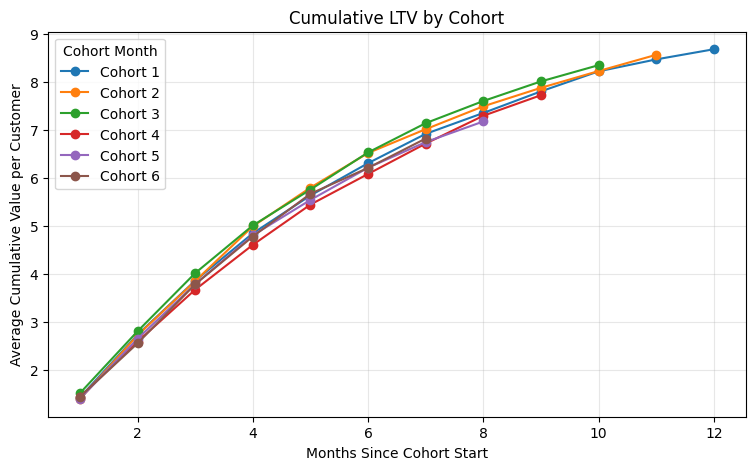

In [4]:
plt.figure(figsize=(9, 5))
for cohort, d in cohort_ltv.groupby("cohort_month"):
    plt.plot(d["months_since_cohort"], d["cumulative_ltv"], marker="o", label=f"Cohort {cohort}")

plt.title("Cumulative LTV by Cohort")
plt.xlabel("Months Since Cohort Start")
plt.ylabel("Average Cumulative Value per Customer")
plt.legend(title="Cohort Month")
plt.grid(True, alpha=0.3)
plt.show()

The cumulative LTV curves show how value builds over time. Earlier cohorts have longer observation windows, so they naturally have more opportunity to accumulate value.

This is why raw total value can be misleading. A cohort with lower total value may simply be younger, not worse.

For practical marketing analytics, cohort LTV is often the first diagnostic before any predictive or causal modeling. It answers a basic question: how does value accumulate as customers age?

## Step 2 — Retention curves

Retention explains whether customers continue to remain active long enough to generate future value.

A customer with high initial conversion value may still have low lifetime value if they churn quickly. A customer with moderate short-term value can become more valuable if they remains active for many periods.

In [5]:
retention = (
    panel.groupby(["cohort_month", "months_since_cohort"], as_index=False)
    .agg(retention_rate=("active_flag", "mean"))
)

retention.head(12)

,cohort_month,months_since_cohort,retention_rate
0,1,1,1.000000
1,1,2,0.838180
2,1,3,0.704440
3,1,4,0.586459
4,1,5,0.487125
5,1,6,0.396892
6,1,7,0.331188
7,1,8,0.270255
8,1,9,0.222863
9,1,10,0.180688


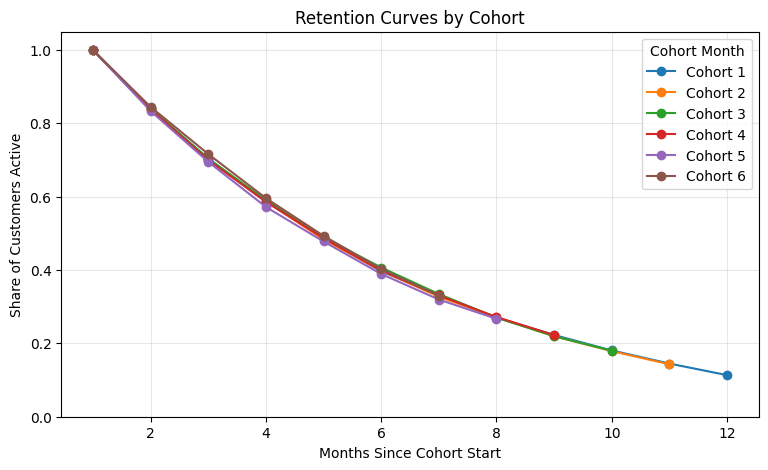

In [6]:
plt.figure(figsize=(9, 5))
for cohort, d in retention.groupby("cohort_month"):
    plt.plot(d["months_since_cohort"], d["retention_rate"], marker="o", label=f"Cohort {cohort}")

plt.title("Retention Curves by Cohort")
plt.xlabel("Months Since Cohort Start")
plt.ylabel("Share of Customers Active")
plt.ylim(0, 1.05)
plt.legend(title="Cohort Month")
plt.grid(True, alpha=0.3)
plt.show()

The retention curve shows the percentage of each cohort that remains active at each customer age.

This is the bridge between conversion modeling and lifetime value. Conversion tells us whether value happens in a given period. Retention tells us how many future periods remain available for value to happen.

In an LTV system, short-term propensity and long-term retention should not be treated as separate business questions. They are two parts of the same expected value problem.

## Step 3 — Survival-adjusted LTV

A survival-style view does not assume that every customer remains active for the full horizon. Instead, each future month is weighted by the probability that the customer is still active.

A compact way to write the idea is:

$$
LTV_i = \sum_{t=1}^{T} P(active_{i,t}) \times E(value_{i,t}) \times discount_t
$$

This is enough for a practical marketing blog post. The goal is not to turn the analysis into a survival modeling tutorial. The goal is to show that future value should be adjusted for the probability of remaining active.

In [13]:
# Estimate empirical survival by customer segment and customer age.
segment_survival = (
    panel.groupby(["customer_segment", "months_since_cohort"], as_index=False, observed=True)
    .agg(empirical_survival=("active_flag", "mean"))
)

segment_value = (
    panel[panel["active_flag"] == 1]
    .groupby(["customer_segment", "months_since_cohort"], as_index=False, observed=True)
    .agg(avg_value_if_active=("monthly_value", "mean"))
)

survival_ltv = segment_survival.merge(
    segment_value,
    on=["customer_segment", "months_since_cohort"],
    how="left"
)

survival_ltv["avg_value_if_active"] = survival_ltv["avg_value_if_active"].fillna(0)
survival_ltv["discount_factor"] = 1 / ((1 + DISCOUNT_RATE_MONTHLY) ** (survival_ltv["months_since_cohort"] - 1))
survival_ltv["survival_adjusted_value"] = (
    survival_ltv["empirical_survival"]
    * survival_ltv["avg_value_if_active"]
    * survival_ltv["discount_factor"]
)

survival_ltv["survival_adjusted_ltv"] = (
    survival_ltv.groupby("customer_segment", observed=True)["survival_adjusted_value"].cumsum()
)

survival_ltv.head(12)

,customer_segment,months_since_cohort,empirical_survival,avg_value_if_active,discount_factor,survival_adjusted_value,survival_adjusted_ltv
0,low_value,1,1.000000,0.720686,1.000000,0.720686,0.720686
1,low_value,2,0.814664,0.673658,0.990099,0.543371,1.264057
2,low_value,3,0.659987,0.754161,0.980296,0.487929,1.751985
3,low_value,4,0.530629,0.868627,0.970590,0.447364,2.199349
4,low_value,5,0.426591,0.732034,0.960980,0.300094,2.499443
5,low_value,6,0.336113,0.854610,0.951466,0.273304,2.772747
6,low_value,7,0.265075,0.840886,0.942045,0.209980,2.982727
7,low_value,8,0.211907,0.848681,0.932718,0.167741,3.150468
8,low_value,9,0.164871,0.687027,0.923483,0.104604,3.255072
9,low_value,10,0.128887,0.809115,0.914340,0.095352,3.350424


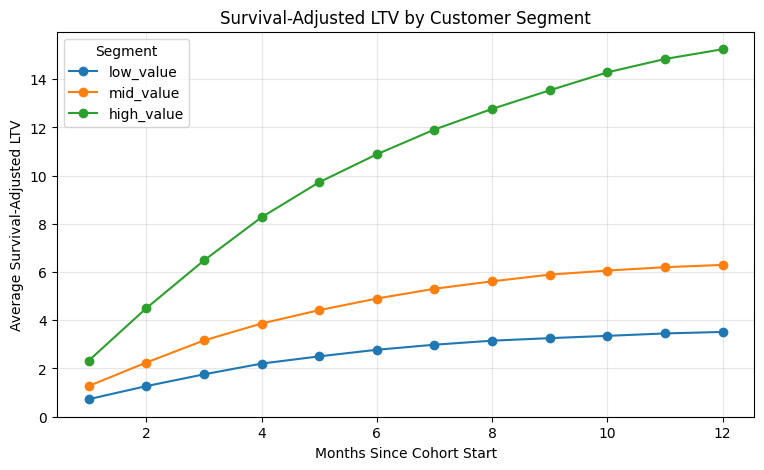

In [8]:
plt.figure(figsize=(9, 5))
for segment, d in survival_ltv.groupby("customer_segment", observed=True):
    plt.plot(d["months_since_cohort"], d["survival_adjusted_ltv"], marker="o", label=str(segment))

plt.title("Survival-Adjusted LTV by Customer Segment")
plt.xlabel("Months Since Cohort Start")
plt.ylabel("Average Survival-Adjusted LTV")
plt.legend(title="Segment")
plt.grid(True, alpha=0.3)
plt.show()

Survival-adjusted LTV separates two mechanisms:

1. How much value active customers generate.
2. How likely customers are to remain active long enough to generate that value.

This is useful because high-value segments can look attractive for two different reasons. They may spend more when active, or they may remain active longer. For marketing decisions, those are different levers.

A retention-based extension is the main additional technical layer beyond standard propensity-and-value ranking.

## Step 4 — Causal / incremental LTV

Observed LTV is not the same as incremental LTV.

If treatment is targeted toward customers who already have high baseline value, then treated customers will have higher LTV even without any treatment effect. A naive comparison will attribute too much value to the marketing action.

This section compares three estimates:

1. Naive observed difference: average treated LTV minus average untreated LTV.
2. Model-adjusted difference: regression adjustment using pre-treatment customer features.
3. True simulated incremental LTV: known because we generated the treatment effect.

In [9]:
# Customer-level LTV over the observed horizon.
customer_ltv = (
    panel.groupby("customer_id", as_index=False)
    .agg(
        observed_ltv=("discounted_monthly_value", "sum"),
        ever_treated=("treatment", "max"),
        avg_treatment_probability=("treatment_probability", "mean"),
        historical_frequency=("historical_frequency", "first"),
        historical_monetary=("historical_monetary", "first"),
        recency=("recency", "first"),
        customer_quality=("customer_quality", "first"),
        baseline_propensity=("baseline_propensity", "first"),
        customer_segment=("customer_segment", "first")
    )
)

naive_treated_ltv = customer_ltv.loc[customer_ltv["ever_treated"] == 1, "observed_ltv"].mean()
naive_untreated_ltv = customer_ltv.loc[customer_ltv["ever_treated"] == 0, "observed_ltv"].mean()
naive_difference = naive_treated_ltv - naive_untreated_ltv

naive_treated_ltv, naive_untreated_ltv, naive_difference

(np.float64(8.894354703021222),
 np.float64(2.717358585046762),
 np.float64(6.1769961179744595))

The naive comparison is easy to compute, but it is not a causal estimate.

Because targeting is biased toward higher-quality customers, the treated group has higher expected value before treatment. The naive difference mixes true treatment impact with pre-existing customer differences.

In [10]:
# Regression adjustment using pre-treatment features.
features = ["ever_treated", "historical_frequency", "historical_monetary", "recency", "baseline_propensity", "customer_segment"]
X = customer_ltv[features]
y = customer_ltv["observed_ltv"]

preprocess = ColumnTransformer(
    transformers=[
        ("segment", OneHotEncoder(drop="first"), ["customer_segment"]),
    ],
    remainder="passthrough"
)

regression_adjustment = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

regression_adjustment.fit(X, y)

# Estimate adjusted treatment effect by predicting each customer twice:
# once as treated and once as untreated, while holding other features fixed.
X_treated = X.copy()
X_untreated = X.copy()
X_treated["ever_treated"] = 1
X_untreated["ever_treated"] = 0

pred_treated = regression_adjustment.predict(X_treated)
pred_untreated = regression_adjustment.predict(X_untreated)

adjusted_difference = np.mean(pred_treated - pred_untreated)
adjusted_difference

np.float64(-0.22865059552685008)

In [11]:
# Approximate the true simulated incremental LTV by replaying the known treatment effects.
# This uses the known conversion and retention lift used in the simulation.
# It is not something available in real observational data; it is included here as a benchmark.

true_incremental_by_month = panel.copy()

# Expected incremental conversion value among active treated observations.
true_incremental_by_month["incremental_conversion_value"] = (
    true_incremental_by_month["active_flag"]
    * true_incremental_by_month["treatment"]
    * true_incremental_by_month["true_conversion_lift"]
    * true_incremental_by_month["baseline_order_value"]
    * true_incremental_by_month["discount_factor"]
)

# Approximate incremental retention value:
# if treatment lowers churn, it preserves some future customer value.
# This simple approximation values the retained month using expected baseline value.
true_incremental_by_month["incremental_retention_value"] = (
    true_incremental_by_month["treatment"]
    * true_incremental_by_month["true_retention_lift"]
    * true_incremental_by_month["baseline_propensity"]
    * true_incremental_by_month["baseline_order_value"]
    * true_incremental_by_month["discount_factor"]
)

true_incremental_total = (
    true_incremental_by_month["incremental_conversion_value"].sum()
    + true_incremental_by_month["incremental_retention_value"].sum()
)

true_incremental_per_treated_customer = true_incremental_total / customer_ltv["ever_treated"].sum()

comparison = pd.DataFrame({
    "estimate": ["Naive observed difference", "Model-adjusted difference", "True simulated incremental LTV"],
    "ltv_difference": [naive_difference, adjusted_difference, true_incremental_per_treated_customer]
})

comparison

,estimate,ltv_difference
0,Naive observed difference,6.176996
1,Model-adjusted difference,-0.228651
2,True simulated incremental LTV,1.609285


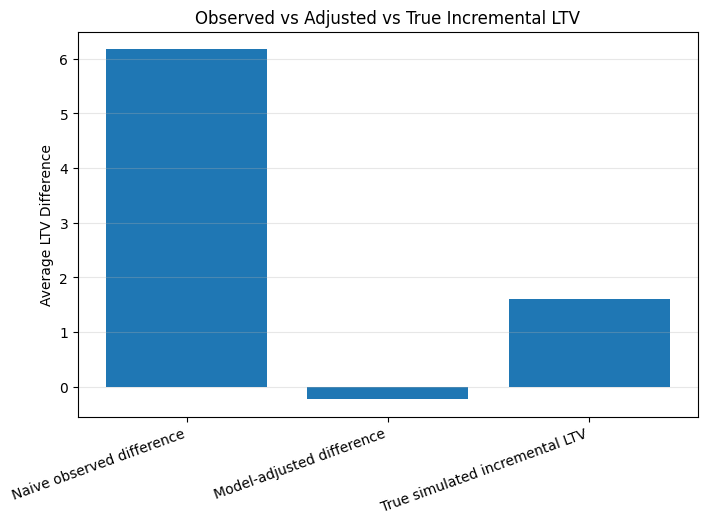

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["estimate"], comparison["ltv_difference"])
plt.title("Observed vs Adjusted vs True Incremental LTV")
plt.ylabel("Average LTV Difference")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

This is the central lesson.

The naive observed difference is usually too high because the treated group was not randomly selected. Treated customers were already more valuable before the treatment.

The model-adjusted estimate moves closer to the simulated truth because it controls for baseline differences. In real business settings, this can be improved further with randomized experiments, uplift models, doubly robust estimation, or other causal methods.

The key point is that LTV is not only a prediction problem. It is also a measurement problem. If the goal is to decide whether a marketing action creates value, the target should be incremental LTV, not observed LTV.

## Practical takeaway

A useful LTV framework combines four pieces:

1. **Cohorts** to understand how value accumulates by customer age.
2. **Retention** to measure whether customers remain active long enough to generate future value.
3. **Survival-adjusted value** to avoid assuming every customer stays active for the full horizon.
4. **Causal validation** to separate observed value from incremental value.

In production, LTV does not have to be a single specialized model. It can be built as a composition of familiar components:

$$
Expected\ Value = Propensity \times Value \times Retention
$$

For decision-making, the stronger version is:

$$
Incremental\ LTV = Incremental\ Propensity \times Value \times Retention
$$

That distinction matters. A high observed LTV customer is not automatically a high incremental-value customer. Marketing decisions should prioritize value that the action actually creates.